In [14]:
# imports
from Bio import Entrez, SeqIO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

Entrez.email = "harshitpatel3358@gmail.com"
sns.set_style("whitegrid")
print("Import Successful")

Import Successful


In [15]:
# GC(Guanine-Cytosine) function
def calculate_gc(sequence):
    sequence = sequence.upper()
    gc = sequence.count('G') + sequence.count('C')
    total = len([b for b in sequence if b in 'ACGT'])
    return round((gc / total) * 100, 2) if total > 0 else 0

In [16]:
# Fetch function
def fetch_phage_broad(host_name, search_name, max_records=40):
    search_term = f'bacteriophage[Title] AND "{search_name}"[Host]'
    handle = Entrez.esearch(db="nuccore", term=search_term, retmax=max_records)
    record = Entrez.read(handle)
    ids = record["IdList"]
    print(f"{host_name}: {len(ids)} IDs found, fetching...")
    
    genomes = []
    for uid in ids:
        try:
            fetch_handle = Entrez.efetch(db="nuccore", id=uid, rettype="gb", retmode="text")
            seq_record = SeqIO.read(fetch_handle, "genbank")
            if len(seq_record.seq) > 10000:
                gc = calculate_gc(str(seq_record.seq))
                genomes.append({
                    "accession": seq_record.id,
                    "host": host_name,
                    "genome_length": len(seq_record.seq),
                    "gc_content": gc,
                    "description": seq_record.description
                })
        except Exception as e:
            print(f"Skipped {uid}: {e}")
        time.sleep(0.4)
    
    print(f"{host_name}: {len(genomes)} valid genomes kept")
    return genomes

print("Fetch Successful")

Fetch Successful


In [5]:
# fetching the data
hosts = [
    ("Escherichia coli", "Escherichia coli"),
    ("Staphylococcus aureus", "Staphylococcus aureus"),
    ("Klebsiella", "Klebsiella pneumoniae"),
    ("Pseudomonas aeruginosa", "Pseudomonas aeruginosa"),
    ("Salmonella", "Salmonella enterica")
]

all_data = []
for host_name, search_name in hosts:
    data = fetch_phage_broad(host_name, search_name, max_records=40)
    all_data.extend(data)
    time.sleep(1)

df = pd.DataFrame(all_data)
df.to_csv("phage_genomes.csv", index=False)
print(f"\nTotal records: {len(df)}")
print(df.groupby("host")["accession"].count())

Escherichia coli: 40 IDs found, fetching...
Escherichia coli: 23 valid genomes kept
Staphylococcus aureus: 40 IDs found, fetching...
Staphylococcus aureus: 6 valid genomes kept
Klebsiella: 24 IDs found, fetching...
Klebsiella: 11 valid genomes kept
Pseudomonas aeruginosa: 40 IDs found, fetching...
Pseudomonas aeruginosa: 34 valid genomes kept
Salmonella: 40 IDs found, fetching...
Salmonella: 7 valid genomes kept

Total records: 81
host
Escherichia coli          23
Klebsiella                11
Pseudomonas aeruginosa    34
Salmonella                 7
Staphylococcus aureus      6
Name: accession, dtype: int64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4716\4226479719.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="host", y="genome_length", palette="Set2", width=0.5)


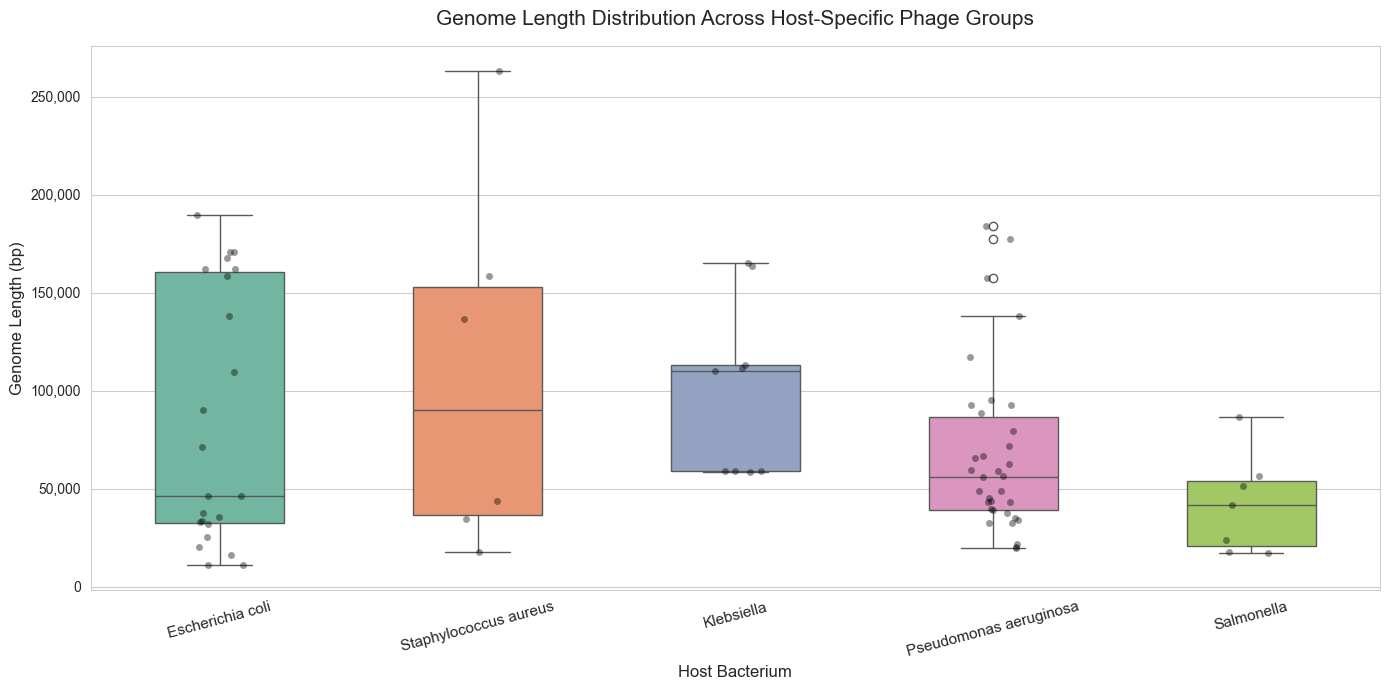

In [17]:
# Plot 1: Genome Length
Q1 = df["genome_length"].quantile(0.25)
Q3 = df["genome_length"].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[df["genome_length"] < (Q3 + 2.5 * IQR)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_clean, x="host", y="genome_length", palette="Set2", width=0.5)
sns.stripplot(data=df_clean, x="host", y="genome_length", color="black", alpha=0.4, size=5, jitter=True)

plt.xticks(rotation=15, fontsize=11)
plt.title("Genome Length Distribution Across Host-Specific Phage Groups", fontsize=15, pad=15)
plt.xlabel("Host Bacterium", fontsize=12)
plt.ylabel("Genome Length (bp)", fontsize=12)

import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig("genome_length_distribution.png", dpi=150)
plt.show()

## Genome Length Distribution

Escherichia coli and Staphylococcus aureus phages show the highest variance 
in genome length, suggesting diverse phage lifestyles infecting these hosts. 
Salmonella phages are notably compact and consistent in size, indicating 
more constrained genome evolution. Klebsiella phages cluster around 
100,000 bp suggesting a dominant phage type for this host.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4716\2238451794.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="host", y="gc_content", palette="Set3", inner="quartile")


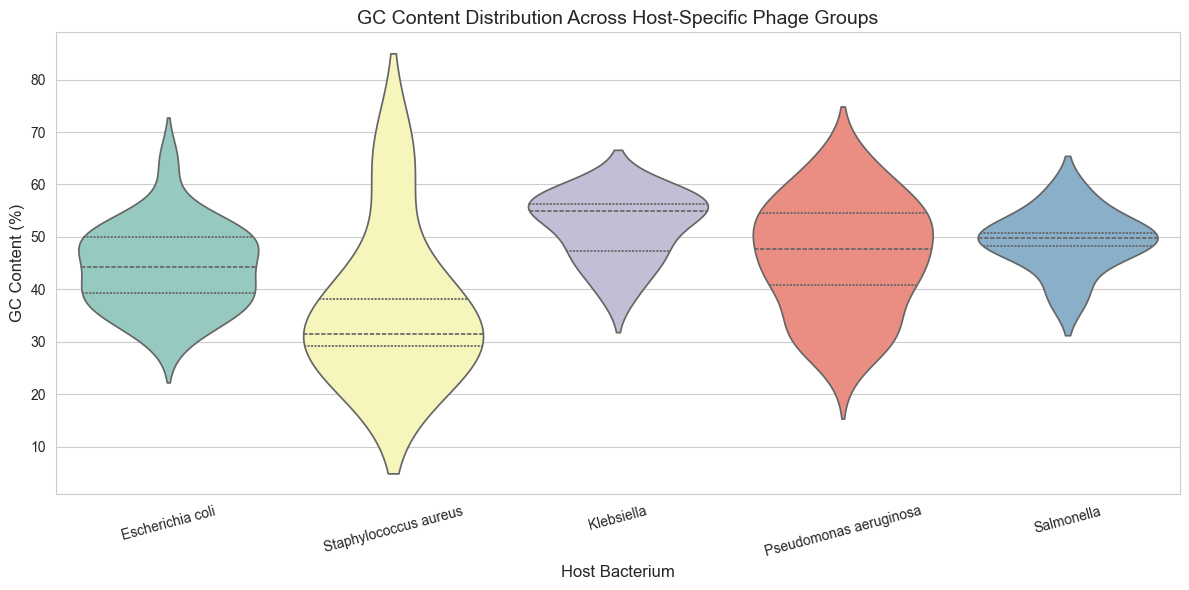

In [18]:
# Plot 2: GC Content
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x="host", y="gc_content", palette="Set3", inner="quartile")
plt.xticks(rotation=15)
plt.title("GC Content Distribution Across Host-Specific Phage Groups", fontsize=14)
plt.xlabel("Host Bacterium", fontsize=12)
plt.ylabel("GC Content (%)", fontsize=12)
plt.tight_layout()
plt.savefig("gc_content_distribution.png", dpi=150)
plt.show()

## GC Content Distribution

Staphylococcus aureus phages show remarkably low GC content (~30%), 
consistent with the low GC genome of S. aureus itself (~33%). In contrast, 
Klebsiella phages show consistently high GC content (~55%), mirroring 
their host's GC-rich genome. This pattern strongly supports co-evolutionary 
adaptation between phage and host at the nucleotide composition level.

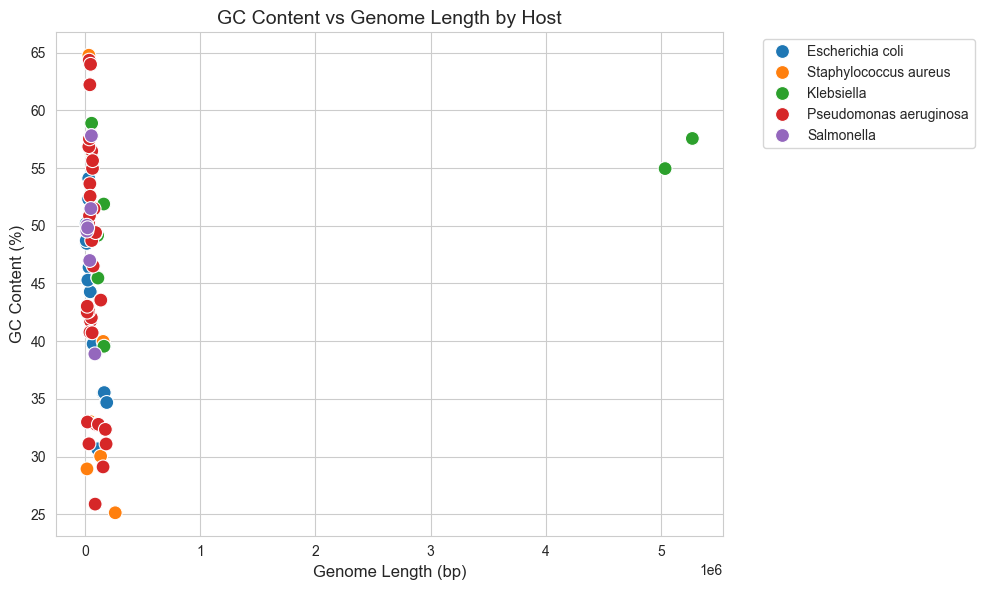

In [19]:
# Plot 3: GC vs Genome Length
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="genome_length", y="gc_content", hue="host", palette="tab10", s=100)
plt.title("GC Content vs Genome Length by Host", fontsize=14)
plt.xlabel("Genome Length (bp)", fontsize=12)
plt.ylabel("GC Content (%)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("gc_vs_length_scatter.png", dpi=150)
plt.show()

## GC Content vs Genome Length

Most phage genomes cluster below 500,000 bp with two notable Klebsiella 
outliers exceeding 5 million bp — likely representing jumbo phages or 
sequencing artifacts worth further investigation. No strong correlation 
exists between genome length and GC content across hosts, suggesting 
these two genomic features are shaped by independent selective pressures.

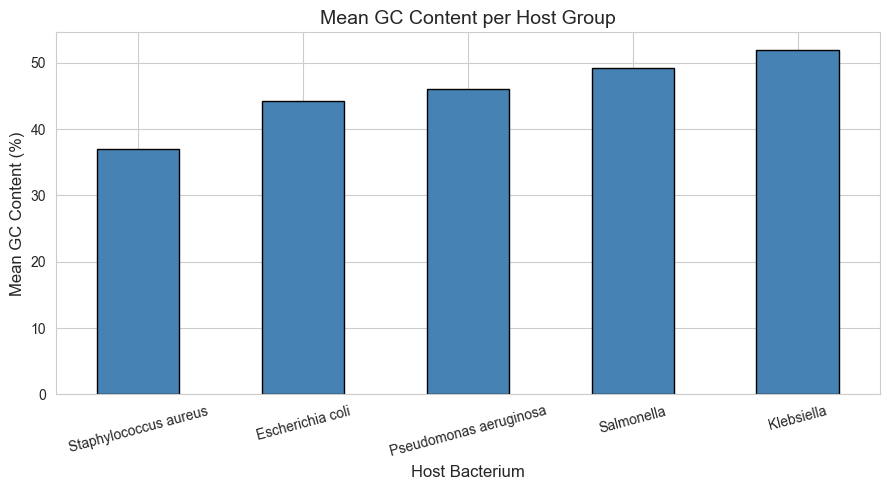

In [20]:
 # Plot 4: Mean GC per Host
mean_gc = df.groupby("host")["gc_content"].mean().sort_values()

plt.figure(figsize=(9, 5))
mean_gc.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Mean GC Content per Host Group", fontsize=14)
plt.ylabel("Mean GC Content (%)", fontsize=12)
plt.xlabel("Host Bacterium", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("mean_gc_per_host.png", dpi=150)
plt.show()

## Mean GC Content Comparison

A clear gradient exists in mean GC content across hosts — from Staphylococcus 
aureus phages (~37%) at the lowest end to Klebsiella phages (~52%) at the 
highest. This ranking closely mirrors the known GC content of the host 
bacterial genomes themselves, providing strong evidence for host-driven 
selection on phage nucleotide composition.

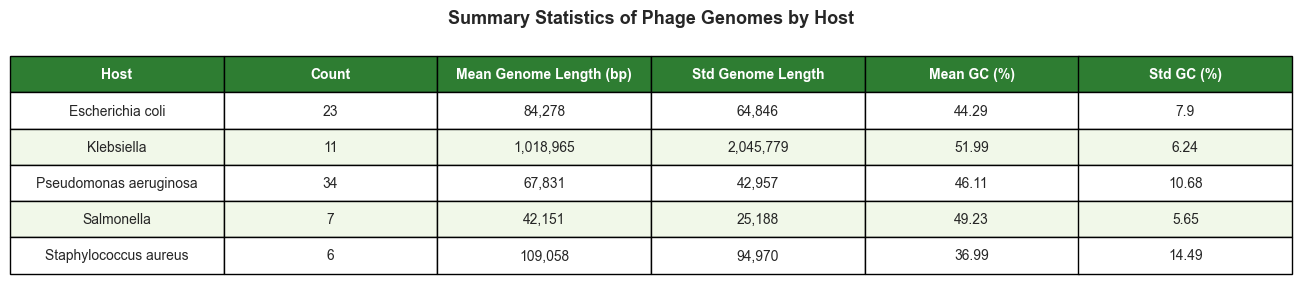

In [21]:
import matplotlib.pyplot as plt
import numpy as np

summary = df.groupby("host").agg(
    Count=("accession", "count"),
    Mean_Genome_Length=("genome_length", "mean"),
    Std_Genome_Length=("genome_length", "std"),
    Mean_GC=("gc_content", "mean"),
    Std_GC=("gc_content", "std")
).round(2).reset_index()

# Rename columns for display
summary.columns = ["Host", "Count", "Mean Genome Length (bp)", "Std Genome Length", "Mean GC (%)", "Std GC (%)"]

# Format large numbers with commas
summary["Mean Genome Length (bp)"] = summary["Mean Genome Length (bp)"].apply(lambda x: f"{x:,.0f}")
summary["Std Genome Length"] = summary["Std Genome Length"].apply(lambda x: f"{x:,.0f}")

fig, ax = plt.subplots(figsize=(13, 3))
ax.axis("off")

table = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.2)

# Style header row
for j in range(len(summary.columns)):
    table[0, j].set_facecolor("#2e7d32")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Alternate row colors
for i in range(1, len(summary) + 1):
    for j in range(len(summary.columns)):
        if i % 2 == 0:
            table[i, j].set_facecolor("#f1f8e9")
        else:
            table[i, j].set_facecolor("#ffffff")

plt.title("Summary Statistics of Phage Genomes by Host", 
          fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("summary_table.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusion

This comparative genomic analysis of 81 bacteriophage genomes across 5 
bacterial hosts reveals clear host-specific patterns in both genome length 
and GC content. Key findings:

- Staphylococcus aureus phages have the lowest GC content (~37%), 
  consistent with their AT-rich host genome
- Klebsiella phages show the highest GC content (~52%) and largest 
  genome sizes
- GC content and genome length appear to be independently evolving 
  features with no strong correlation
- Host GC composition appears to be a major driver of phage GC content, 
  supporting co-evolutionary adaptation

These findings are relevant to bacteriophage therapy, where genomic 
compatibility between phage and host may influence infection efficiency 
and therapeutic outcomes.

Data: 81 genomes from NCBI Nucleotide Database via Biopython Entrez API.